# 사전과제_0928


# <연관분석>

# <span style="color: purple"> 1. 연관분석이란? <span>
### <span style="color: orange"> 1-1 연관분석의 정의 <span>
- 연관분석 : 상품이나 서비스를 구매하는 등 일련의 거래나 사건 내에 존재하는 항목 간의 일정한 연관 규칙을 발견하는 분석 <br>
- 정답값이 존재하지 않기에 비지도 학습에 해당<br>
- 연관분석 알고리즘 : aripori, FP-Growth
### <span style="color: orange"> 1-2 연관규칙 분석 <span>
- 형태 : **A 를 구매** 하였을 때 **B 또한 구매**할 것이다.(if-then/A->B)<br>
      - 조건절 : 만일 ~ 라면<br>
      - 결과절 : 조건절 뒷부분<br>
      - 아이템 집합 : 조건절이나 결과절을 구성하는 아이템들의 집합 -> **상호 배반** 이어야한다<br>
      - 예시 : 맥주를 구매하는 사람은 기저귀를 함꼐 구매한다. 샌드위치를 먹는 사람은 탄산수를 함께 마신다.<br>
- 주의 : 상관관계를 파악하는 것이지 인과관계는 알 수 없다.
      - A->B 의 신뢰도는 "함께 자주 나타난다"이지 *원인-결과* 관계는 아니다.
    1. 실험이 아닌 **관찰 데이터**이기 때문이다. / 무언가를 사게하는 원인이 통제되지 않는다.
    2. 방향성은 그저 **수학적 비율**이다.
    3. 상관관계 != 인과관계


# <span style="color: purple"> 2. 주요 개념 <span>
### <span style="color: orange"> 2-1 **적절한** 연관 규칙의 조건 <span>
1. 두 품목이 함께 구매한 경우의 수가 일정 수준의 이상이어야한다. = **일정 이상의 지지도**<br>
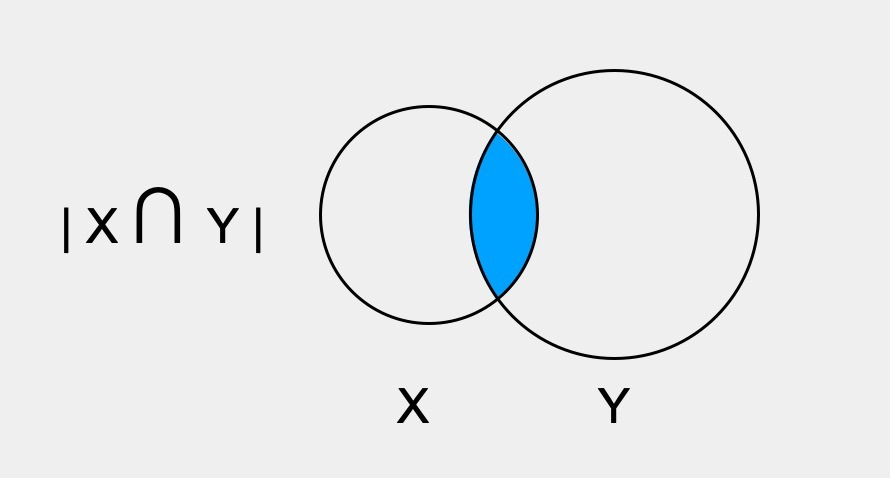
    * 지지도 : 전체 거래 항목 중 품목 A ,B가 **동시에** 포함하는 거래의 비율 <br>
   
              - 지지율이 낮다면 : 우연일 수 있다 / 실행 가능한 인사이트를 도출하기 어렵다
2. 품목 A를 포함하는 거래 중 B를 구입하는 경우의 수가 일정 수준 이상이어야한다. = **일정 수준 이상의 신뢰도** <br>
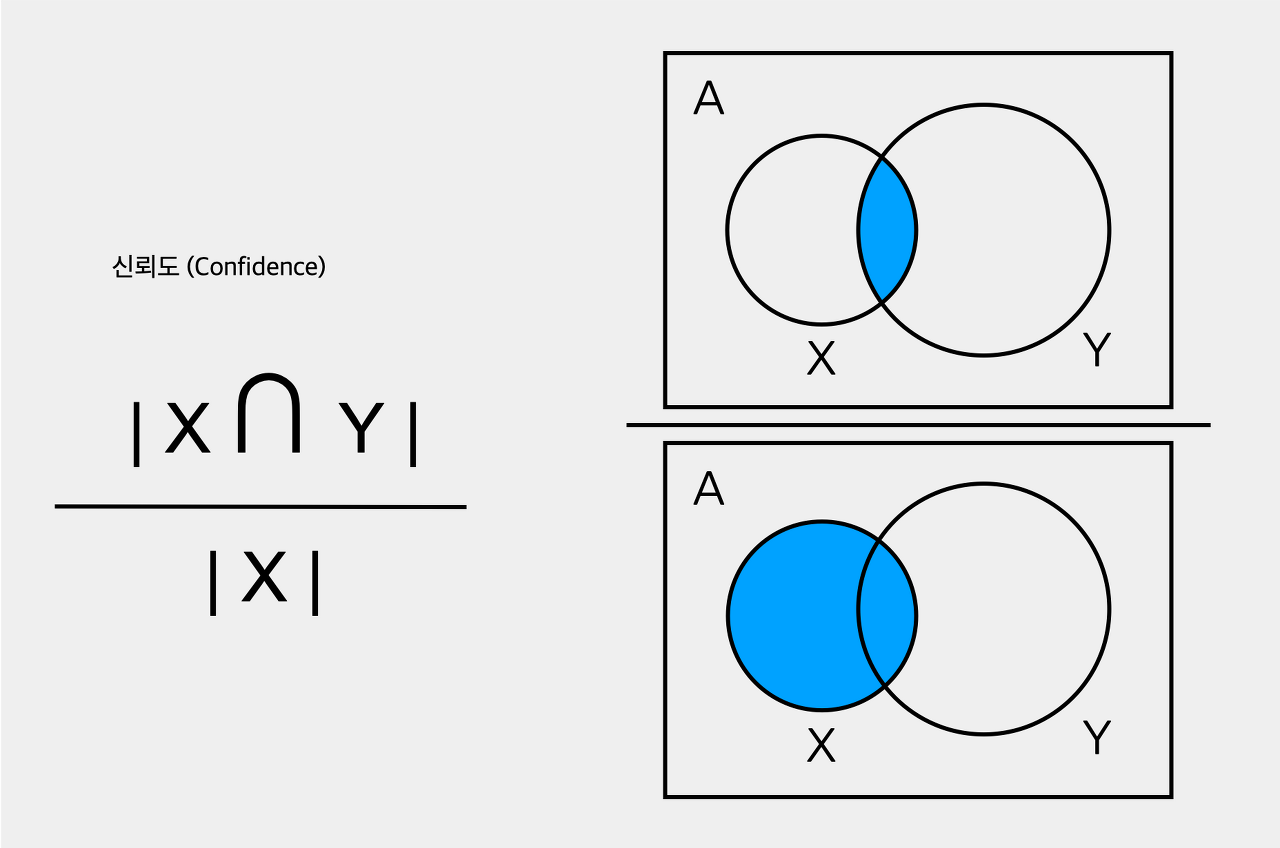
    * 신뢰도 : 품목 A를 포함하는 거래 수 중에 품목 A와 B가 동시에 포함하는 거래의 비율, 신뢰도/P(A)<br>
<br>
              - 신뢰도가 낮다면 : 의미가 없는 연관 규칙이며 추천 실패로 이어진다. <br>
-> 예시 : 나초-> 콜라 지지도 10프로/ 신뢰도 75프로 : 신뢰도가 높다고 무조건 좋은 규칙은 아니다. 나초-> 콜라의 확률은 아무나 콜라를 사는 확률 85프로보다 낮은 확률로 오히려 깎아먹는 것이었다. 그렇기에 유의미한 상관관계를 확인하는 **향상도** 측정 필요

### <span style="color: orange"> 2-2 연관 분석의 평가 측도 <span>
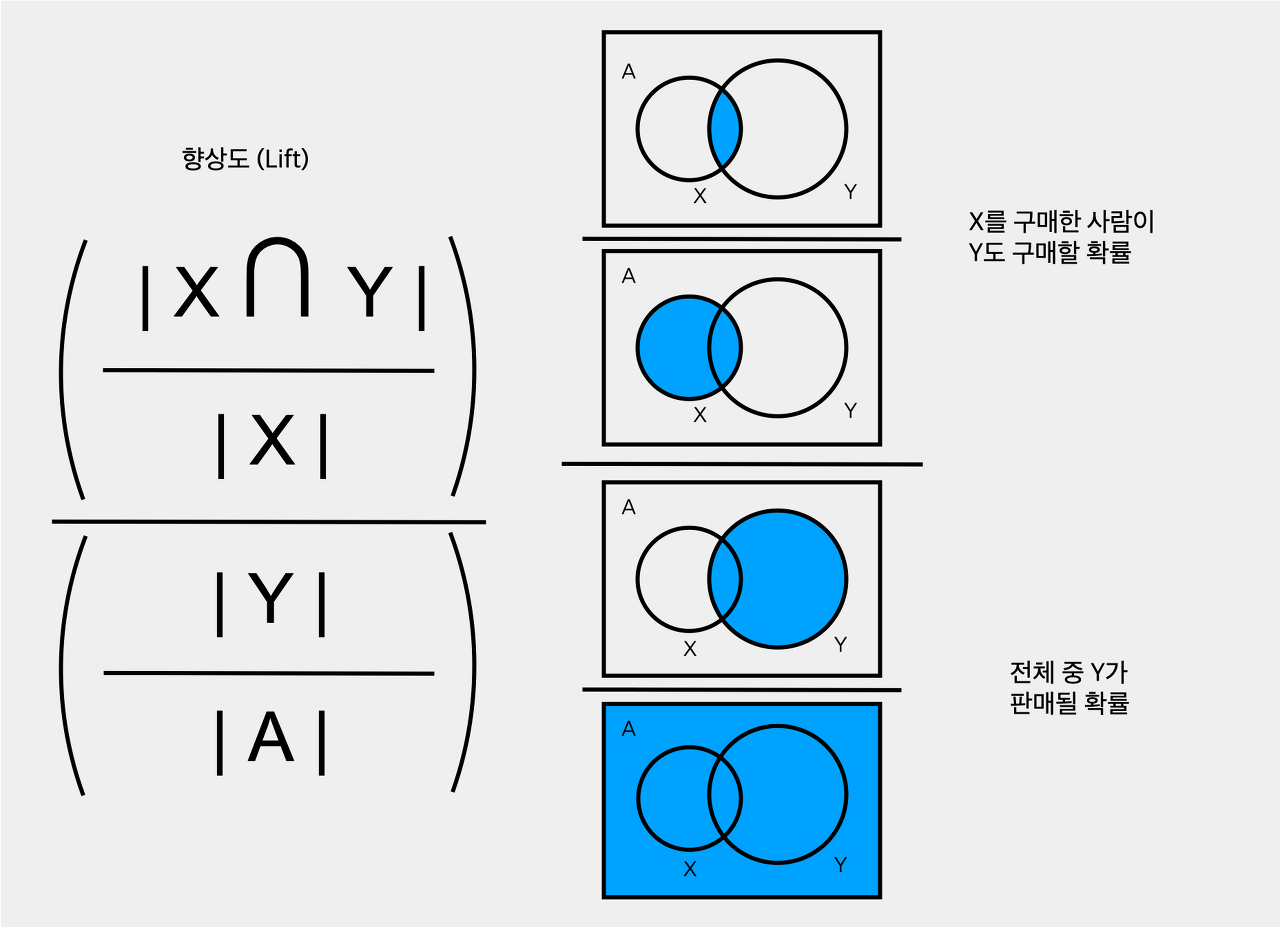
- 향상도 - A가 주어지지 않았을 때의 품목 B 확률 대비 품목 A가 주어졌을 때의 품목 B의 확률 증가 비율 : 신뢰도 /P(B) <br>
1. 독립일 때의 기댓값 : <br> 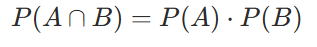 <br> A를 샀다는 사실이 B를 살 확률에 영향을 주지 않기에 향상도는 항상 1이다. <br><-> 독립이 아니라면 A/B를 샀다는 사실이 B/A에 영향을 준다는 의미로 향상도는 1보다 크거나 작다
2. 실제 동시 발생 확률 :  향상도가 1보다 크면 양의 연관성 / 1보다 작으면 음의 연관성 
* 총 규칙 수 구하는 식 = 3^n - 2^(n+1)+1

# <span style="color: purple"> 3. 활용 사례 <span>
< 월마트 케이스 > : 허리케인이 오면 딸기맛 팝타르트를 트럭으로 실어 보내라!
- 딸기맛 팝타르트는 허리케인 직전에 평상시의 7배 속도로 팔렸으며 허리케인 직전 판매 1위 품목은 맥주였다 -> 허리케인 경로상의 매장에 딸기 팝타르트와 맥주를 실은 트럭을 미리 내려보냈다.
1. 지지도 : '허리케인 경보 기간 중 발생한 '재난 대비 용품'(A)과 '딸기 팝타르트'(B)" -> 허리케인 상황에서 지지도 상승 / 특정 조건만 뺴서 봤더니 유의미 했다는 점!
2. 신뢰도 : P(B|A)가 충분히 높았기에 팝타르트가 재난 대비 용품에 따라 들어오는 경향이 있음을 파악 
3. 향상도 : 평상시 구매 확률 대비 7배로 1보다 훨씬 큼 -> 명백히 독립이 아니며 강한 상관관계가 존재한다. 맛의 의미보다는 향상도만 높다는 사실로 의사결정

# <span style="color: purple"> 4. 연관 분석 알고리즘 <span>
### <span style="color: orange"> 4-1 Apriori 알고리즘 <span>
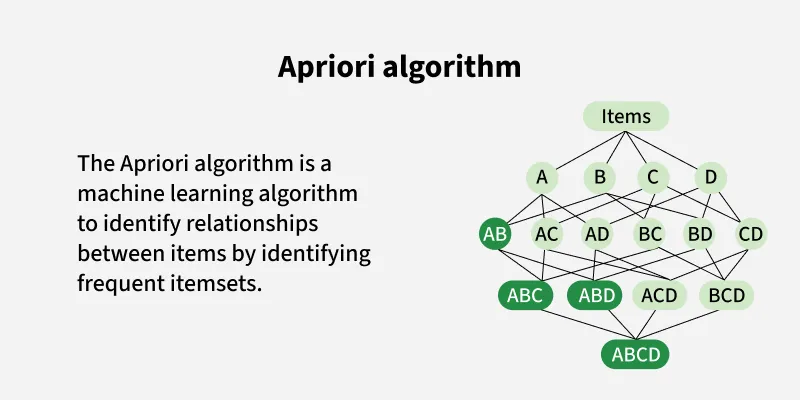
- 선형적 경험을 이용한다!
- 배경 : 가능한 모든 조합을 시도하는 것은 매우 비효율 적이다. (상품 개수가 많을 수록 조합 수는 기하급수적으로 늘어남)
- 알고리즘 : 특정 조합이 자주 발생하지 않는다면 이의 결과물까지 모두 후보에서 **배제하는 방식**의 알고리즘
- 장점 : 하나의 조합만 검사해도 파생된 다른 조합들까지 후보에서 배제할 수 있기에 연산량이 효율적으로 줄어든다. 수많은 연관 구매 패턴이 발견된다. 원리가 간단하며 이해분석에 좋다
- 단점 : 여전히 데이터가 커지면 속도가 느려진다.
- 알고리즘 프로세스 : 빈발 항목 집합을 찾고 -> 단계적으로 조합을 생성하고 필터링한다.
* 빈발 항목 집합 : 일정한 최소 지지도를 넘는 항목들의 조합 <br>
      1. 단일 항목 집합 생성 : 최소 지지도를 넘는 항목만 다음 단계로 <br>
      2. 2개 항목 집합 생성 : 1단계에서 선별된 상품으로 조합을 만들고 지지도 계산 후 최소 지지도 넘지 않으면 제거 <Br>
      3. 더 큰 항목 집합 생성 : 생성 후 또한 지지도를 계산해서 최소 지지도 넘지 않으면 제거 <br>
      4. 최종 빈발 항목 집합 선정 : 마지막으로 남은 집합들로 연관 규칠을 생성한다. (지지도 신뢰도 향상도 계산해서 가장 유용한 것 선택)
### <span style="color: orange"> 4-2 FP Growth 알고리즘 <span>
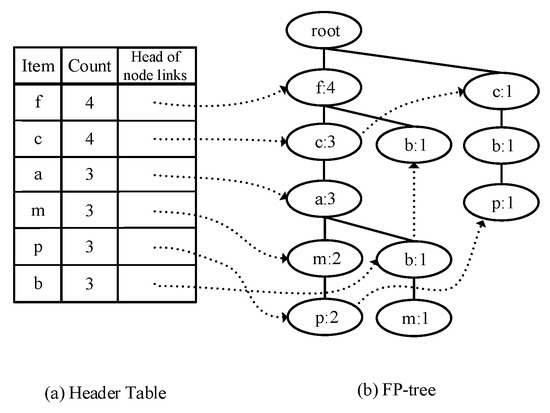
- Apriori 연산 속도 문제를 해결할 수 있게 자료구조를 이용한 알고리즘
- 배경 : apriori 알고리즘의 단점 = 데이터가 커질수록 속도가 느려진다.
- 알고리즘 : <br>빈발 품목 집합을 효율적으로 찾아낸다. <br> FP tree라는 구조로 Apriori 를 효과적으로 구현한다. <br> 모든 거래를 확인해서 각 아이템마다 지지도를 계산하고 최소 지지도 이상의 아이템만 선택 <br> 
   - 모든 거래에서 빈도가 높은 아이템을 순서대로 정렬하고 부모 노드를 중심으로 거래를 자식 노드에 추가해주며 트리를 생성한다. <br>
   - 새로운 아이템이 나오면 부모 노드부터 시작하고 그렇지 않으면 기존 노드에서 확정한다<br>
   - 이 과정을 모든 거래에서 반복해서 FP Tree를 만들고 최소 지지도 이상의 패턴만 추출한다.
- 알고리즘 프로세스 : 모든 항목 빈도 계산 후 -> 최소 지지도 이상인 항목만을 남긴다.<br>
        1. 데이터셋 확인 <br>
        2. 빈도 순으로 재정렬 : 거래를 빈도순으로 재정렬하고 가장 구매된 항목을 제일 먼저 오도록한다. <br>
        3. FP - 트리 생성 : 재정렬 된 데이터로 트리를 생성한다. 각 거래는 노드로 표현, 동일한 항목이면 기존 노드에 연결시키고 새로운 항목은 새로운 노드로 추가한다.<br>
        4. 빈발 항목 집합 추출: 특정 항목을 기준으로 부분트리를 만들어 빈발 항목 집합을 추출한다. <br>
        5. 연관 규칙 도출 : FP 트리에서 도출된 빈발 항목 집합을 바탕으로 연관규칙을 만든다. 지지도, 신뢰도, 향상도 등을 계산해서 가장 유용한 규칙을 선택한다.
- 장점 : 데이터를 두 번만 스캔하기에 Apriori보다 훨씬 빠르다. 후보 아이템세트를 만들지 않아도 Tree만 구성하면 된다.
- 단점 : 대용량 데이터셋에서 메모리를 효율적으로 사용하지 않는다. Apriori에 비해 설계하기 어렵고 지지도 계싼은 무조건 FP-Tree가 만들어져야 가능하다.
    